In [87]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict.csv
/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv


In [88]:
df = pd.read_csv('/kaggle/input/datasets/mohansacharya/graduate-admissions/Admission_Predict_Ver1.1.csv')

In [89]:
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1,0.87
496,497,337,117,5,5.0,5.0,9.87,1,0.96
497,498,330,120,5,4.5,5.0,9.56,1,0.93
498,499,312,103,4,4.0,5.0,8.43,0,0.73


In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [91]:
df.duplicated().sum()

np.int64(0)

In [92]:
# Serial no is not important so we remove it
df.drop(columns=['Serial No.'],inplace=True)

In [93]:
df

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,337,118,4,4.5,4.5,9.65,1,0.92
1,324,107,4,4.0,4.5,8.87,1,0.76
2,316,104,3,3.0,3.5,8.00,1,0.72
3,322,110,3,3.5,2.5,8.67,1,0.80
4,314,103,2,2.0,3.0,8.21,0,0.65
...,...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1,0.87
496,337,117,5,5.0,5.0,9.87,1,0.96
497,330,120,5,4.5,5.0,9.56,1,0.93
498,312,103,4,4.0,5.0,8.43,0,0.73


In [94]:
X  = df.iloc[:,0:-1]
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [95]:
y = df.iloc[:,-1]
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [96]:
from sklearn.model_selection import train_test_split
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42
)

In [97]:
X_train

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
249,321,111,3,3.5,4.0,8.83,1
433,316,111,4,4.0,5.0,8.54,0
19,303,102,3,3.5,3.0,8.50,0
322,314,107,2,2.5,4.0,8.27,0
332,308,106,3,3.5,2.5,8.21,1
...,...,...,...,...,...,...,...
106,329,111,4,4.5,4.5,9.18,1
270,306,105,2,2.5,3.0,8.22,1
348,302,99,1,2.0,2.0,7.25,0
435,309,105,2,2.5,4.0,7.68,0


# Data is unscaled and columns have large number compare to each other so we use the Minmax scaler not standerd beacuse we know the upper limit and the lower limit

# Applied minmax scaler

In [98]:
from sklearn.preprocessing import MinMaxScaler

In [99]:
scaler = MinMaxScaler()

In [100]:
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Make neural network

In [101]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense
from keras import Sequential

In [123]:
model = Sequential()
model.add(Dense(7,activation='relu',input_dim = 7 ))
model.add(Dense(20,activation='relu'))
model.add(Dense(17,activation='relu'))
model.add(Dense(12,activation='relu'))
model.add(Dense(1,activation='linear')) # linear beacuse it is regression problem


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [124]:
model.summary()

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_40 (Dense)                │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 20)             │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 17)             │           357 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_43 (Dense)                │ (None, 12)             │           216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_44 (Dense)                │ (None, 1)              │            13 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802 (3.13 KB)

 Trainable params: 802 (3.13 KB)

 Non-trainable params: 0 (0.00 B)

In [125]:
# loss function 
model.compile(loss='mean_squared_error',optimizer='Adam',metrics=['r2_score'])

In [126]:
history = model.fit(X_train_scaled,y_train,epochs=130,validation_split=0.2)

Epoch 1/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 0.5521 - r2_score: -27.8549 - val_loss: 0.4960 - val_r2_score: -21.6910
Epoch 2/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.4308 - r2_score: -21.5154 - val_loss: 0.4158 - val_r2_score: -18.0237
Epoch 3/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.3479 - r2_score: -17.1805 - val_loss: 0.3278 - val_r2_score: -13.9953
Epoch 4/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.2479 - r2_score: -11.9534 - val_loss: 0.2150 - val_r2_score: -8.8376
Epoch 5/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1369 - r2_score: -6.1527 - val_loss: 0.1047 - val_r2_score: -3.7924
Epoch 6/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0583 - r2_score: -2.0485 - val_loss: 0.0424 - val_r2_score: -0.9398
Epoch 7/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0357 - r2_score: -0.8663 - val_loss: 0.0284 - val_r2_score: -0.2985
Epoch 8/130
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0323 - r2_score: -0.6885 - v

In [127]:
y_pred = model.predict(X_test_scaled)
y_pred

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[0.87165695],
       [0.7892149 ],
       [0.56794584],
       [0.69001985],
       [0.7852312 ],
       [0.8276503 ],
       [0.43916684],
       [0.64596266],
       [0.7987551 ],
       [0.8358348 ],
       [0.6913366 ],
       [0.69510275],
       [0.6851268 ],
       [0.8987833 ],
       [0.7859195 ],
       [0.48188704],
       [0.82925063],
       [0.6100469 ],
       [0.53598803],
       [0.6350173 ],
       [0.6568748 ],
       [0.58330506],
       [0.687771  ],
       [0.7544343 ],
       [0.756245  ],
       [0.6596312 ],
       [0.96359986],
       [0.8079527 ],
       [0.628437  ],
       [0.7492984 ],
       [0.5517977 ],
       [0.6929063 ],
       [0.53571635],
       [0.8653877 ],
       [0.65594345],
       [0.7351716 ],
       [0.5681555 ],
       [0.9450622 ],
       [0.67738825],
       [0.6701338 ],
       [0.89026505],
       [0.5818958 ],
       [0.6341829 ],
       [0.8550594 ],
       [0.8938146 ],
       [0.5668596 ],
       [0.92508775],
       [0.829

In [128]:
from sklearn.metrics import r2_score
r2_score(y_test,y_pred)

0.810702447756426

Text(0.5, 1.0, 'val vs val_loss')

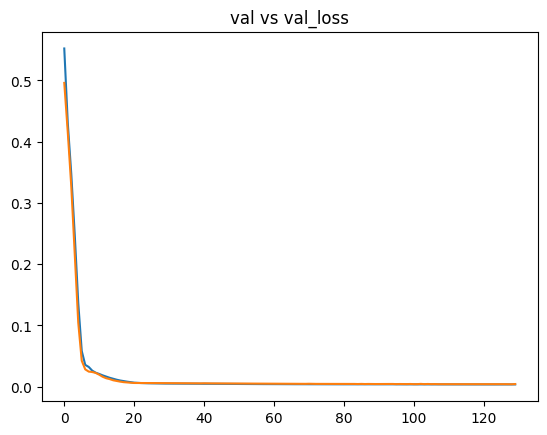

In [131]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('val vs val_loss')

Text(0.5, 1.0, 'r2_score vs val_r2_score')

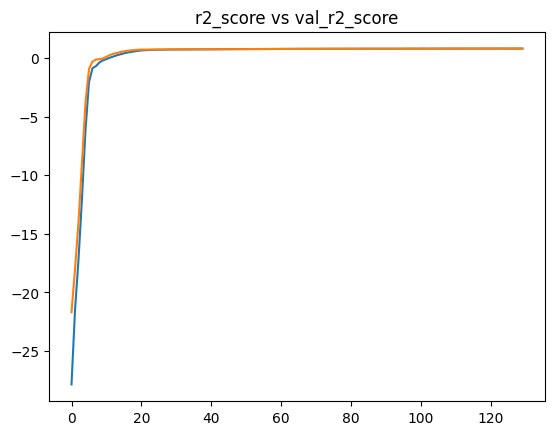

In [133]:
plt.plot(history.history['r2_score'])
plt.plot(history.history['val_r2_score'])
plt.title('r2_score vs val_r2_score')